## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

1. Load the golub.csv dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

In [5]:
from google.colab import files
uploaded = files.upload()

Saving golub.csv to golub (1).csv


In [9]:
import pandas as pd

# Load dataset
df = pd.read_csv("golub.csv")

# Check labels
print(df['cancer'].unique())

# Convert ALL variants → 1, everything else (AML) → 0
df['target'] = df['cancer'].apply(lambda x: 1 if 'all' in str(x).lower() else 0)

# Features and target
X = df.drop(columns=['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'target'])
y = df['target']

# Ensure numeric
y = y.astype(float)

# Sanity check
print(y.unique())
print(y.value_counts())

['allB' 'allT' 'aml']
[1. 0.]
target
1.0    47
0.0    25
Name: count, dtype: int64


2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

Mean Squared Error: 1.2654643687920398e-30


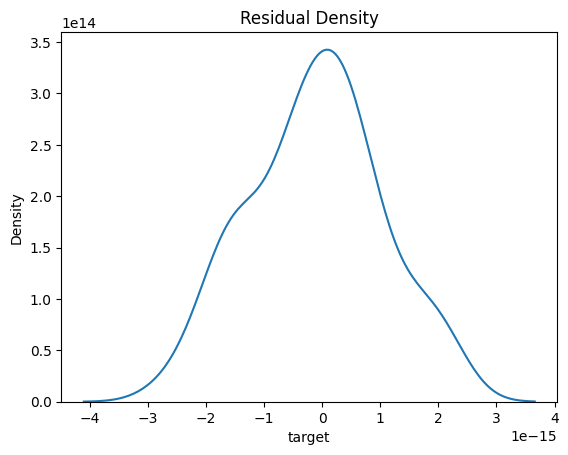

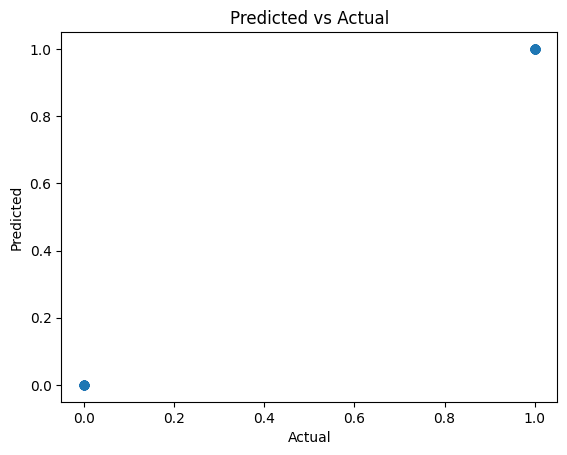

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

lr = LinearRegression()
lr.fit(X, y)

y_pred = lr.predict(X)

mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)

residuals = y - y_pred

sns.kdeplot(residuals)
plt.title("Residual Density")
plt.show()

plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

In [11]:
from sklearn.model_selection import cross_val_score
import numpy as np

# 5-fold cross-validation MSE
cv_mse = -cross_val_score(lr, X, y, cv=5, scoring='neg_mean_squared_error')

print("Cross-Validated MSE:", np.mean(cv_mse))

Cross-Validated MSE: 0.06012309872062145


4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

Number of selected genes: 34
Number of discarded genes: 7095

Selected genes:
['HG3549-HT3751_at', 'J04164_at', 'L38941_at', 'M11147_at', 'M11722_at', 'M17733_at', 'M19507_at', 'M26602_at', 'M27891_at', 'M33680_at', 'M63138_at', 'M77232_rna1_at', 'M91036_rna1_at', 'M96326_rna1_at', 'U14968_at', 'X04500_at', 'X17042_at', 'X78992_at', 'Z70759_at', 'L06797_s_at', 'D49824_s_at', 'M25079_s_at', 'X57351_s_at', 'V00594_s_at', 'U05255_s_at', 'X03689_s_at', 'M14328_s_at', 'M14483_rna1_s_at', 'M26708_s_at', 'Y00787_s_at', 'Z19554_s_at', 'X56681_s_at', 'HG2887-HT3031_at', 'M33600_f_at']


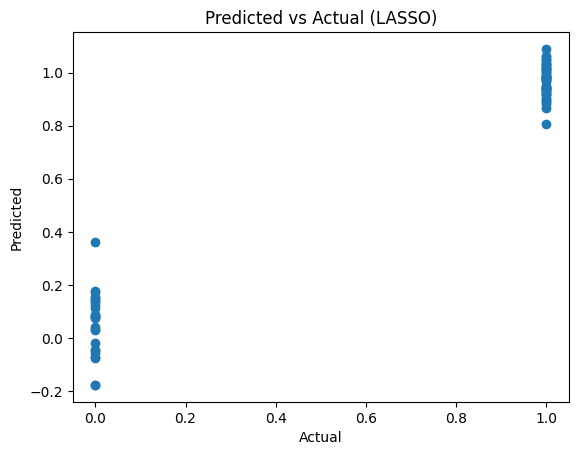

In [12]:
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt
import numpy as np

# Fit LASSO with cross-validation
lasso = LassoCV(cv=5, max_iter=10000)
lasso.fit(X, y)

# Predictions
y_pred_lasso = lasso.predict(X)

# Selected genes (non-zero coefficients)
selected_genes = X.columns[lasso.coef_ != 0]

# Counts
num_selected = len(selected_genes)
num_removed = X.shape[1] - num_selected

print("Number of selected genes:", num_selected)
print("Number of discarded genes:", num_removed)

print("\nSelected genes:")
print(list(selected_genes))

# Scatter plot
plt.scatter(y, y_pred_lasso)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (LASSO)")
plt.show()

5. Make a plot that shows the cross validated MSE as  𝑎𝑙𝑝ℎ𝑎  varies. For what values of  𝛼  is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

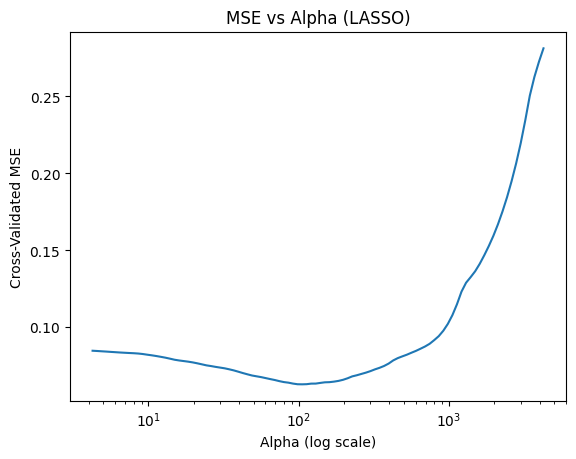

Optimal alpha: 105.24436668425457


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Get alpha values and corresponding CV MSE
alphas = lasso.alphas_
mse_path = lasso.mse_path_.mean(axis=1)

# Plot
plt.plot(alphas, mse_path)
plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Cross-Validated MSE")
plt.title("MSE vs Alpha (LASSO)")
plt.show()

# Optimal alpha
print("Optimal alpha:", lasso.alpha_)

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

Linear regression performs almost perfectly on the training set because the number of features (genes) is much larger than the number of observations. This allows the model to fit the training data extremely closely, even capturing noise, which leads to overfitting. As a result, the training error is very low, but the model does not generalize well to new data.

In contrast, LASSO introduces an L1 regularization penalty that shrinks many coefficients to zero, effectively performing feature selection. By reducing the complexity of the model and eliminating irrelevant or noisy features, LASSO lowers variance and improves generalization. Although it may not fit the training data as perfectly as linear regression, it achieves better predictive performance on unseen data by balancing bias and variance more effectively.

7. Why do regularization methods lend themselves to scenarios like precision health?

Regularization methods are well-suited for precision health because these datasets are typically high-dimensional, with thousands of genetic features but relatively few patient samples. In such settings, standard models like linear regression tend to overfit by capturing noise rather than meaningful biological signals.

Regularization techniques, such as LASSO, address this by penalizing model complexity and shrinking many coefficients toward zero. This reduces overfitting, improves generalization, and helps identify a smaller subset of important genes that are most predictive of the outcome. As a result, regularization not only improves predictive accuracy but also enhances interpretability, which is especially important in medical applications where understanding which features drive predictions can inform clinical decisions.

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

Applying methods like LASSO in precision health carries important risks because model predictions can directly influence medical decisions. While LASSO performs feature selection, it may incorrectly discard genes that are actually important (false negatives) or retain genes that are not truly relevant (false positives), especially in noisy, high-dimensional data. This can lead to misleading conclusions about which biological factors drive disease.

Additionally, LASSO is sensitive to the specific dataset used. With small sample sizes, the selected features may not be stable across different samples, reducing reliability and reproducibility. If such unstable models are used in practice, they could result in inconsistent or incorrect treatment recommendations.

There are also broader concerns around bias and data quality. If the training data is not representative of all patient populations, the model’s predictions may be less accurate or even harmful for underrepresented groups. Given that clinical interventions may follow from these predictions, errors can have serious consequences for patient outcomes.

Therefore, while LASSO is a powerful tool, its results must be carefully validated, interpreted with caution, and combined with clinical expertise before being used to guide healthcare decisions.